In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [ ]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'


In [2]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Cameroon/data'

In [ ]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [3]:
GID2_NAME = 'Nord'
YEAR = '2020'

In [ ]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [4]:
df = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled.csv', encoding=enc)

In [5]:
df.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,2020-01-01,8.221831,12.291199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-01,8.221831,12.291199,NaN,NaN,2020-01-01,8.250038,12.250056,2019-12-31,2019-12-31,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,2020-01-02,8.221831,12.291199,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,2020-01-02,8.221831,12.291199,14803.0,NaN,2020-01-02,8.250038,12.250056,2020-01-01,2020-01-01,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,2020-01-03,8.221831,12.291199,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,2020-01-03,8.221831,12.291199,14803.0,NaN,2020-01-03,8.250038,12.250056,2020-01-02,2020-01-02,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,2020-01-04,8.221831,12.291199,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,2020-01-04,8.221831,12.291199,14778.0,14415.0,2020-01-04,8.250038,12.250056,2020-01-03,2020-01-03,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,2020-01-04,8.221831,12.291199,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.21047,0.088939,0.017273,0.025342,0.006728,0.025342,2020-01-05,8.221831,12.291199,14778.0,14419.0,2020-01-05,8.250038,12.250056,2020-01-04,2020-01-04,0.0


In [6]:
date_columns = [col for col in df.columns if 'dt_placement' in col.lower() or 'date' in col.lower()]
print(f"Date columns: {date_columns}")
for col_name in date_columns:
    df[col_name] = pd.to_datetime(df[col_name])

# df['dt_placement'] = pd.to_datetime(df['dt_placement'])
# df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
# df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
# df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
# df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
# df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Date columns: ['dt_placement', 'indices_image_date', 'lst_image_date', 'indices_image_date.1', 'dt_placement_minus_1', 'dt_placement_minus_1_avail']


Text(0.5, 1.0, 'Year: 2020')

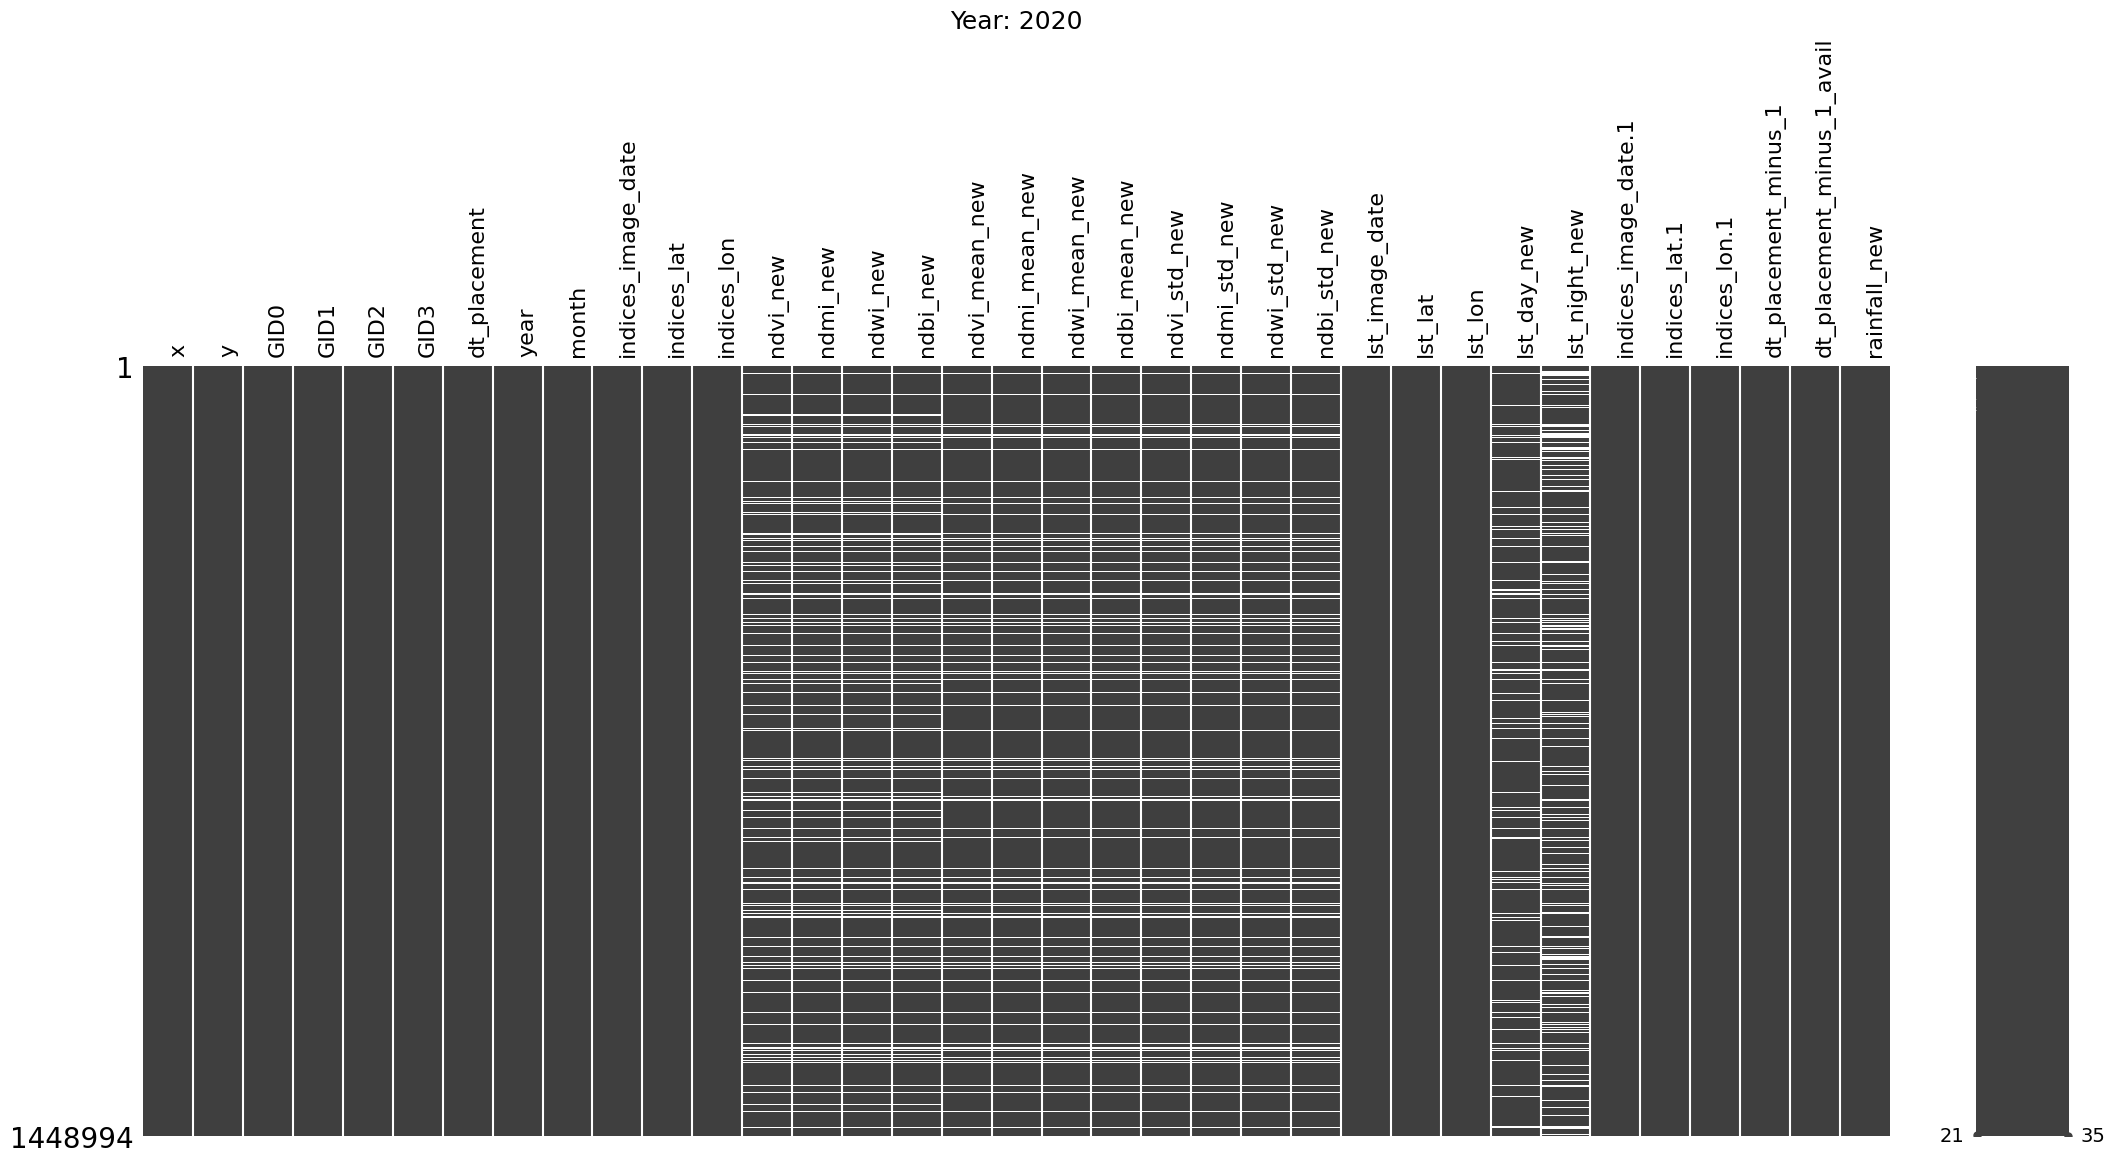

In [7]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [8]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,14.7878
13,ndmi_new,14.7967
14,ndwi_new,14.7878
15,ndbi_new,14.7967
16,ndvi_mean_new,11.3682
17,ndmi_mean_new,11.3840
18,ndwi_mean_new,11.3682
19,ndbi_mean_new,11.4482
20,ndvi_std_new,11.3682
21,ndmi_std_new,11.3840


In [9]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,14.7878
11,ndmi,14.7967
12,ndwi,14.7878
13,ndbi,14.7967
14,ndvi_mean,11.3682
15,ndmi_mean,11.3840
16,ndwi_mean,11.3682
17,ndbi_mean,11.4482
18,ndvi_std,11.3682
19,ndmi_std,11.3840


In [11]:
df2 = df.copy()

In [12]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [13]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,14.7878
11,ndmi,14.7967
12,ndwi,14.7878
13,ndbi,14.7967
14,ndvi_mean,11.3682
15,ndmi_mean,11.3840
16,ndwi_mean,11.3682
17,ndbi_mean,11.4482
18,ndvi_std,11.3682
19,ndmi_std,11.3840


In [14]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [15]:
df2.reset_index(drop=True, inplace=True)

In [16]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.00
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-27,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-28,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-29,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,14943.0,14470.0,0.00
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-30,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,15328.0,14470.0,0.00


Text(0.5, 1.0, 'Year: 2020')

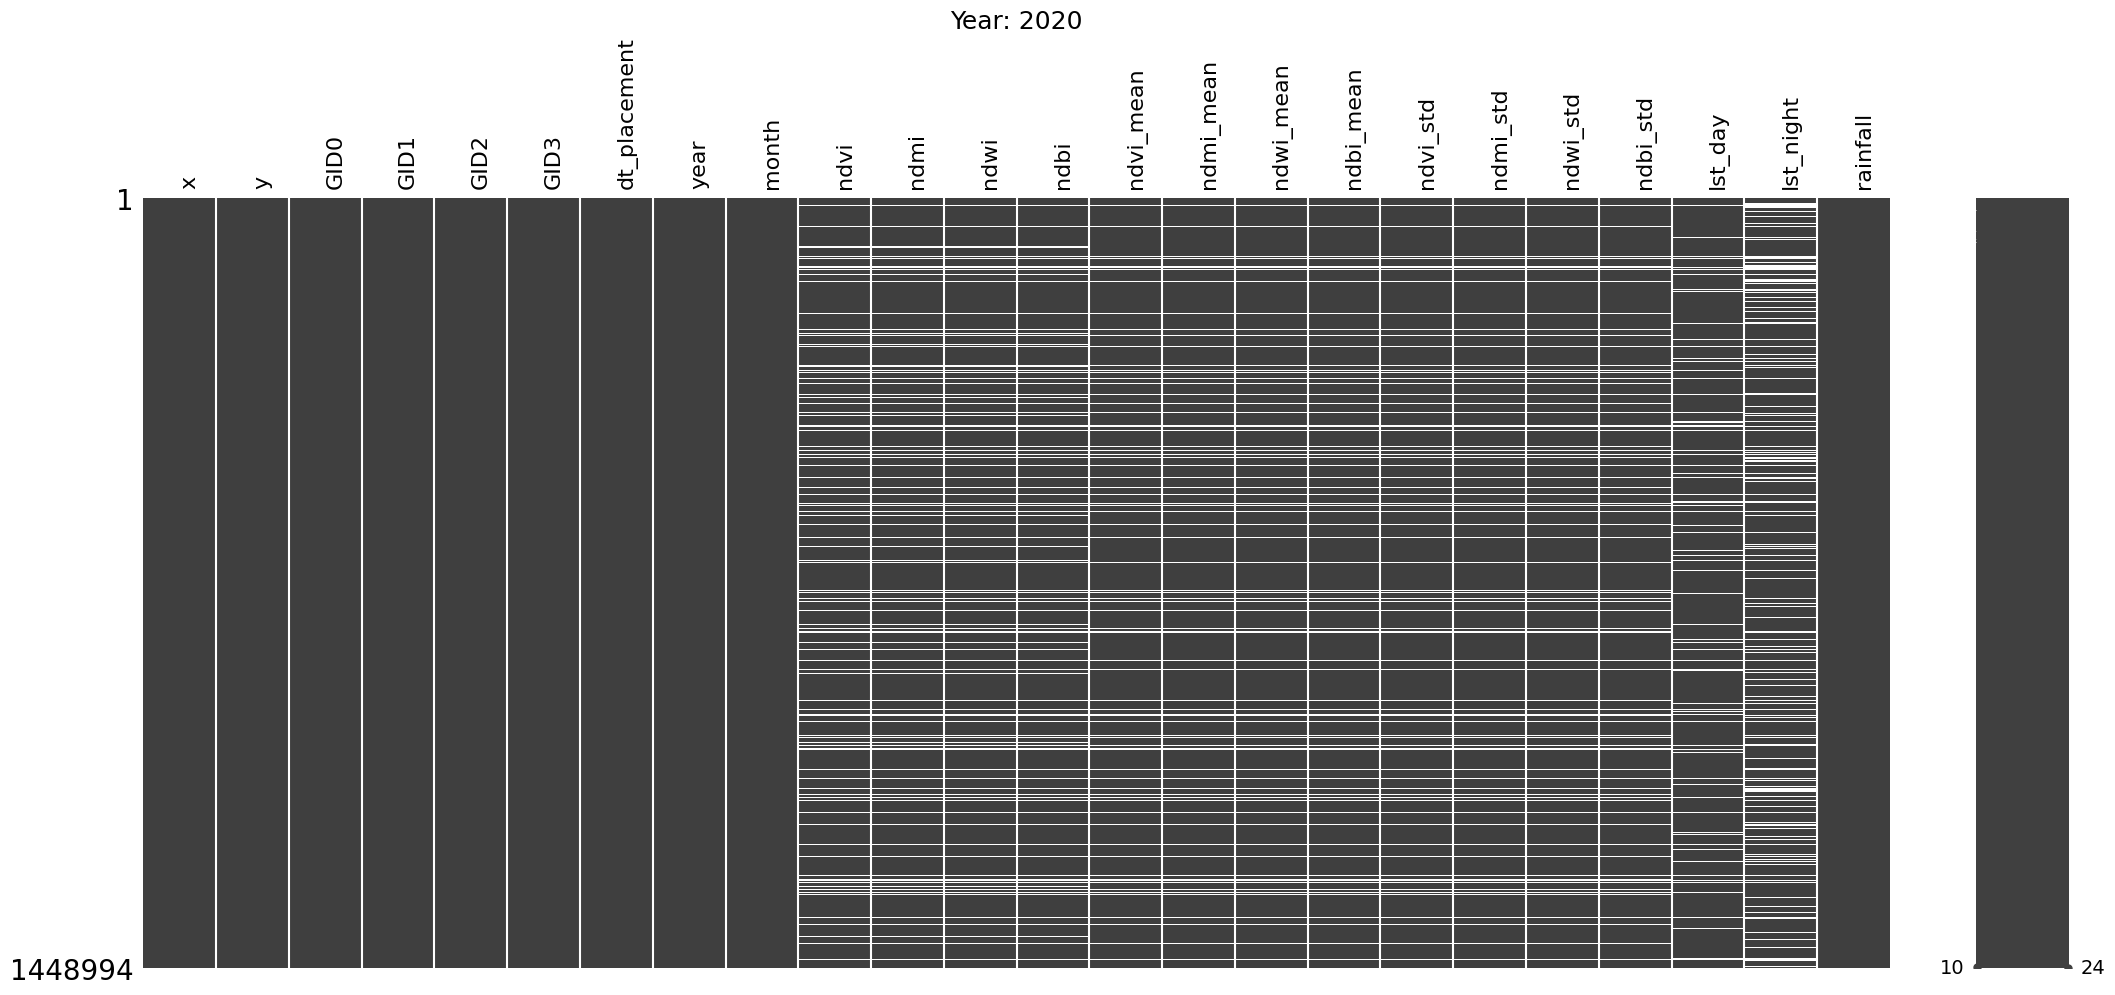

In [17]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [18]:
#df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')

In [19]:
df2.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8')

In [20]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-01,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-02,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00
2,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-03,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14803.0,NaN,0.00
3,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-04,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14415.0,0.00
4,12.29306,8.21972,nord,faro,poli,balkossa,2020-01-05,2020,1,0.190113,-0.110807,-0.215332,0.110807,0.201625,-0.088939,-0.210470,0.088939,0.017273,0.025342,0.006728,0.025342,14778.0,14419.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-27,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-28,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.246605,-0.105652,-0.248674,0.105652,0.050398,0.050228,0.028863,0.050228,14943.0,14470.0,0.00
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-29,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,14943.0,14470.0,0.00
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2020-12-30,2020,12,0.240237,-0.124587,-0.262723,0.124587,0.301446,-0.001540,-0.304972,0.001540,0.034961,0.039764,0.039052,0.039764,15328.0,14470.0,0.00
